In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\victo\miniconda3\Lib\_strptime.py' for module '_strptime': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "C:\Users\victo\miniconda3\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in _find_and_lo

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)

from src.utils import configure_logger

import pandas as pd

from typing import Any
from qqe.src.GNN.training.utils import collect_dataset_paths
from qqe.src.GNN.training.runners import MODEL_REGISTRY
from qqe.src.GNN.training.train_config import TrainConfig

from collections.abc import Callable
Loader = Callable[..., Any]

# Regime distributions

In [4]:
import numpy as np

from qqe.src.experiments.plotting import _plot_SRE_distribution
from qqe.src.GNN.dataset_builder import (
    DataGenConfig,
    RegimeDistribution,
    SamplingConfig,
    run_dataset_pipeline,
)
PROJECT_ROOT = Path().resolve().parent

In [ ]:
n_qubits = (4, 6, 8, 10)
n_layers = (1, 2, 4, 8, 16, 40, 50, 80, 100)
n_seeds = 25

## Clifford

### Dataset creation

In [17]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        clifford=RegimeDistribution(
            regimes=["zero", "low", "medium", "high"],
            probabilities=[0.25, 0.25, 0.25, 0.25],
        ),
    )

In [18]:
cliff_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["clifford"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path("../outputs/data/SRE_distributions/test_1"),
    max_configs=None,
)

In [19]:
run_dataset_pipeline(
    config=cliff_config,
    families=["clifford"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

Parallel dataset generation: 100%|██████████| 900/900 [02:20<00:00,  6.40it/s]


### Visualization

In [23]:
import torch

In [24]:
rows = []

for path in Path("../outputs/data/SRE_distributions/test_1/clifford").rglob("*.pt"):
    d = torch.load(path, map_location="cpu")

    meta = d["meta"]
    controls = meta.get("sampling_controls", {})
    realized = meta.get("realized_stats", {})

    row = {
        "path": str(path),
        "family": meta["family"],
        "regime": meta["regime"],
        "n_qubits": meta["n_qubits"],
        "n_layers": meta["n_layers"],
        "seed": meta["seed"],
        "sre": float(d.get("sre", np.nan)),
        "sre_density": float(d.get("sre", np.nan)) / meta["n_qubits"],
    }

    row.update({f"ctrl_{k}": v for k, v in controls.items()})
    row.update({f"real_{k}": v for k, v in realized.items()})

    rows.append(row)

df = pd.DataFrame(rows)

<Figure size 640x480 with 0 Axes>

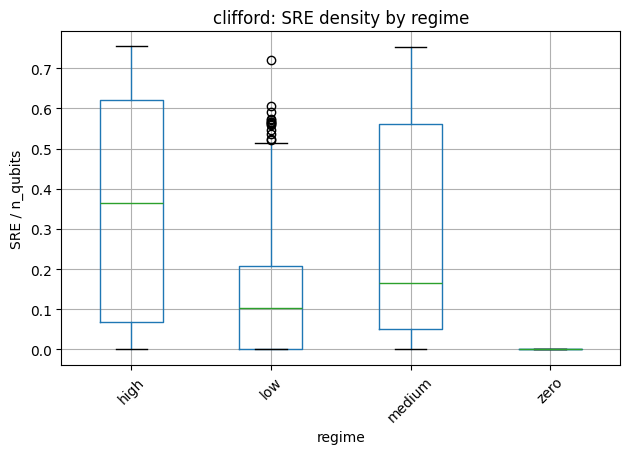

In [25]:
import matplotlib.pyplot as plt

for family in df["family"].unique():
    sub = df[(df["family"] == family) & np.isfinite(df["sre_density"])]

    plt.figure()
    sub.boxplot(column="sre_density", by="regime", rot=45)
    plt.title(f"{family}: SRE density by regime")
    plt.suptitle("")
    plt.ylabel("SRE / n_qubits")
    plt.tight_layout()
    plt.show()

## Haar

In [20]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        haar=RegimeDistribution(
            regimes=["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
            probabilities=[1/6] * 6,
        ),
    )

In [21]:
haar_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["haar"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path("../outputs/data/SRE_distributions/test_1"),
    max_configs=None,
)

In [22]:
run_dataset_pipeline(
    config=haar_config,
    families=["haar"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

Parallel dataset generation: 100%|██████████| 900/900 [01:53<00:00,  7.91it/s]


In [26]:
rows = []

for path in Path("../outputs/data/SRE_distributions/test_1/haar").rglob("*.pt"):
    d = torch.load(path, map_location="cpu")

    meta = d["meta"]
    controls = meta.get("sampling_controls", {})
    realized = meta.get("realized_stats", {})

    row = {
        "path": str(path),
        "family": meta["family"],
        "regime": meta["regime"],
        "n_qubits": meta["n_qubits"],
        "n_layers": meta["n_layers"],
        "seed": meta["seed"],
        "sre": float(d.get("sre", np.nan)),
        "sre_density": float(d.get("sre", np.nan)) / meta["n_qubits"],
    }

    row.update({f"ctrl_{k}": v for k, v in controls.items()})
    row.update({f"real_{k}": v for k, v in realized.items()})

    rows.append(row)

df = pd.DataFrame(rows)

<Figure size 640x480 with 0 Axes>

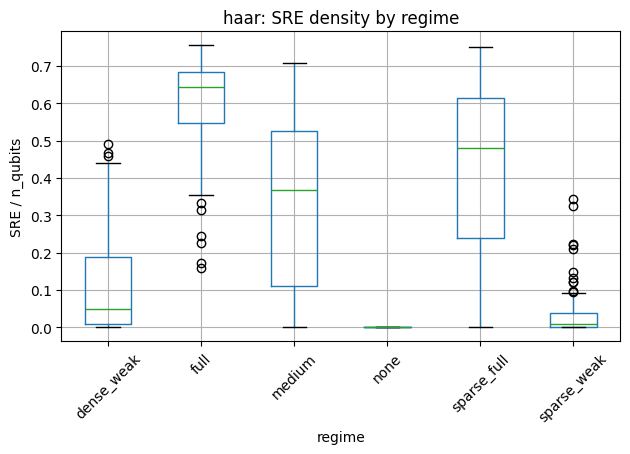

In [27]:
for family in df["family"].unique():
    sub = df[(df["family"] == family) & np.isfinite(df["sre_density"])]

    plt.figure()
    sub.boxplot(column="sre_density", by="regime", rot=45)
    plt.title(f"{family}: SRE density by regime")
    plt.suptitle("")
    plt.ylabel("SRE / n_qubits")
    plt.tight_layout()
    plt.show()

## Random rotations

In [28]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        random=RegimeDistribution(
            regimes=["identity_like", "clifford_like", "small_angles", "generic"],
            probabilities=[0.25, 0.25, 0.25, 0.25],
        ),
    )

In [29]:
rot_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["random"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path("../outputs/data/SRE_distributions/test_1"),
    max_configs=None,
)

In [31]:
run_dataset_pipeline(
    config=rot_config,
    families=["random"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

Parallel dataset generation: 100%|██████████| 900/900 [01:57<00:00,  7.65it/s]


<Figure size 640x480 with 0 Axes>

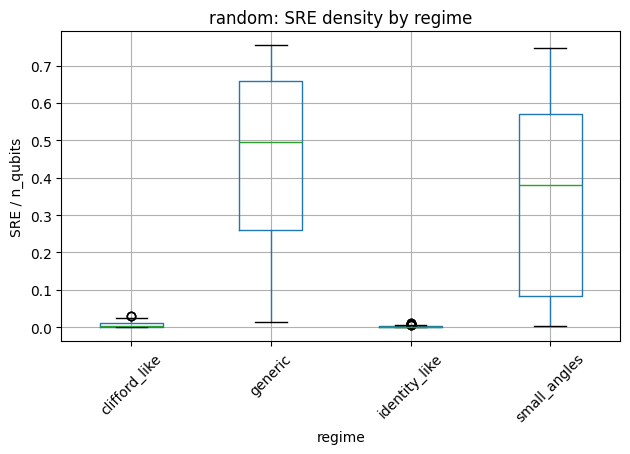

In [32]:
rows = []

for path in Path("../outputs/data/SRE_distributions/test_1/random").rglob("*.pt"):
    d = torch.load(path, map_location="cpu")

    meta = d["meta"]
    controls = meta.get("sampling_controls", {})
    realized = meta.get("realized_stats", {})

    row = {
        "path": str(path),
        "family": meta["family"],
        "regime": meta["regime"],
        "n_qubits": meta["n_qubits"],
        "n_layers": meta["n_layers"],
        "seed": meta["seed"],
        "sre": float(d.get("sre", np.nan)),
        "sre_density": float(d.get("sre", np.nan)) / meta["n_qubits"],
    }

    row.update({f"ctrl_{k}": v for k, v in controls.items()})
    row.update({f"real_{k}": v for k, v in realized.items()})

    rows.append(row)

df = pd.DataFrame(rows)

for family in df["family"].unique():
    sub = df[(df["family"] == family) & np.isfinite(df["sre_density"])]

    plt.figure()
    sub.boxplot(column="sre_density", by="regime", rot=45)
    plt.title(f"{family}: SRE density by regime")
    plt.suptitle("")
    plt.ylabel("SRE / n_qubits")
    plt.tight_layout()
    plt.show()

## Quansistor

In [33]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        quansistor=RegimeDistribution(
            regimes=[
                "identity_like",
                "weak",
                "moderate",
                "structured_equal_ab",
                "structured_opposite_ab",
                "generic_uniform",
            ],
            probabilities=[1/6] * 6,
        ),
    )

In [34]:
quansistor_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["quansistor"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path("../outputs/data/SRE_distributions/test_1"),
    max_configs=None,
)

In [35]:
run_dataset_pipeline(
    config=quansistor_config,
    families=["quansistor"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

Parallel dataset generation: 100%|██████████| 900/900 [01:56<00:00,  7.75it/s]


<Figure size 640x480 with 0 Axes>

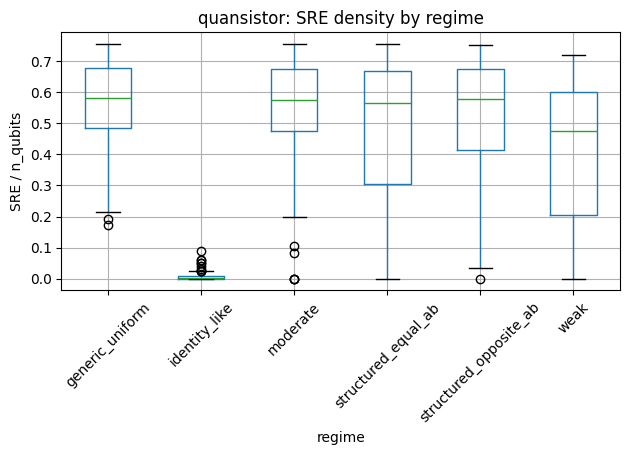

In [36]:
rows = []

for path in Path("../outputs/data/SRE_distributions/test_1/quansistor").rglob("*.pt"):
    d = torch.load(path, map_location="cpu")

    meta = d["meta"]
    controls = meta.get("sampling_controls", {})
    realized = meta.get("realized_stats", {})

    row = {
        "path": str(path),
        "family": meta["family"],
        "regime": meta["regime"],
        "n_qubits": meta["n_qubits"],
        "n_layers": meta["n_layers"],
        "seed": meta["seed"],
        "sre": float(d.get("sre", np.nan)),
        "sre_density": float(d.get("sre", np.nan)) / meta["n_qubits"],
    }

    row.update({f"ctrl_{k}": v for k, v in controls.items()})
    row.update({f"real_{k}": v for k, v in realized.items()})

    rows.append(row)

df = pd.DataFrame(rows)

for family in df["family"].unique():
    sub = df[(df["family"] == family) & np.isfinite(df["sre_density"])]

    plt.figure()
    sub.boxplot(column="sre_density", by="regime", rot=45)
    plt.title(f"{family}: SRE density by regime")
    plt.suptitle("")
    plt.ylabel("SRE / n_qubits")
    plt.tight_layout()
    plt.show()